"""
Social Media Impact on Teen Mental Health
Analyzing how social media affects stress, anxiety, and sleep

About Dataset
Dataset Overview
This dataset studies how social media use affects the mental health of teenagers. It includes daily habits like social media hours, sleep, stress, anxiety, and physical activity.

The goal is to understand if high social media use is linked with problems like stress, anxiety, and depression. The data helps in analyzing behavior and building machine learning models to predict mental health risk.

Overall, this dataset is useful for basic research and for creating models that can help in early detection of mental health issues in teenagers.

Dataset Tags
mental health, teen health, social media impact, depression prediction, anxiety analysis, machine learning, dataset, behavioral data, health analytics, AI in healthcare

About this file

A dataset of teenagers’ social media habits and mental health factors for basic analysis and ML use.

source: https://www.kaggle.com/datasets/algozee/teenager-menthal-healy/data

https://www.kaggle.com/code/tahafarhan/teen-mental-health-eda#%F0%9F%93%8A-Table-of-Contents
"""

In [28]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [29]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [30]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')

In [31]:
print("\n=== DESCRIPTIVE STATISTICS ===")
print(df.describe())


=== DESCRIPTIVE STATISTICS ===
               age  daily_social_media_hours  sleep_hours  \
count  1200.000000               1200.000000  1200.000000   
mean     15.928333                  4.536667     6.449417   
std       2.021947                  2.029599     1.442677   
min      13.000000                  1.000000     4.000000   
25%      14.000000                  2.800000     5.200000   
50%      16.000000                  4.500000     6.500000   
75%      18.000000                  6.300000     7.600000   
max      19.000000                  8.000000     9.000000   

       screen_time_before_sleep  academic_performance  physical_activity  \
count               1200.000000           1200.000000        1200.000000   
mean                   1.740333              2.990383           1.014500   
std                    0.716660              0.576758           0.582185   
min                    0.500000              2.000000           0.000000   
25%                    1.100000       

In [32]:
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())


=== MISSING VALUES ===
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [33]:
df.dtypes

age                           int64
gender                          str
daily_social_media_hours    float64
platform_usage                  str
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level        str
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

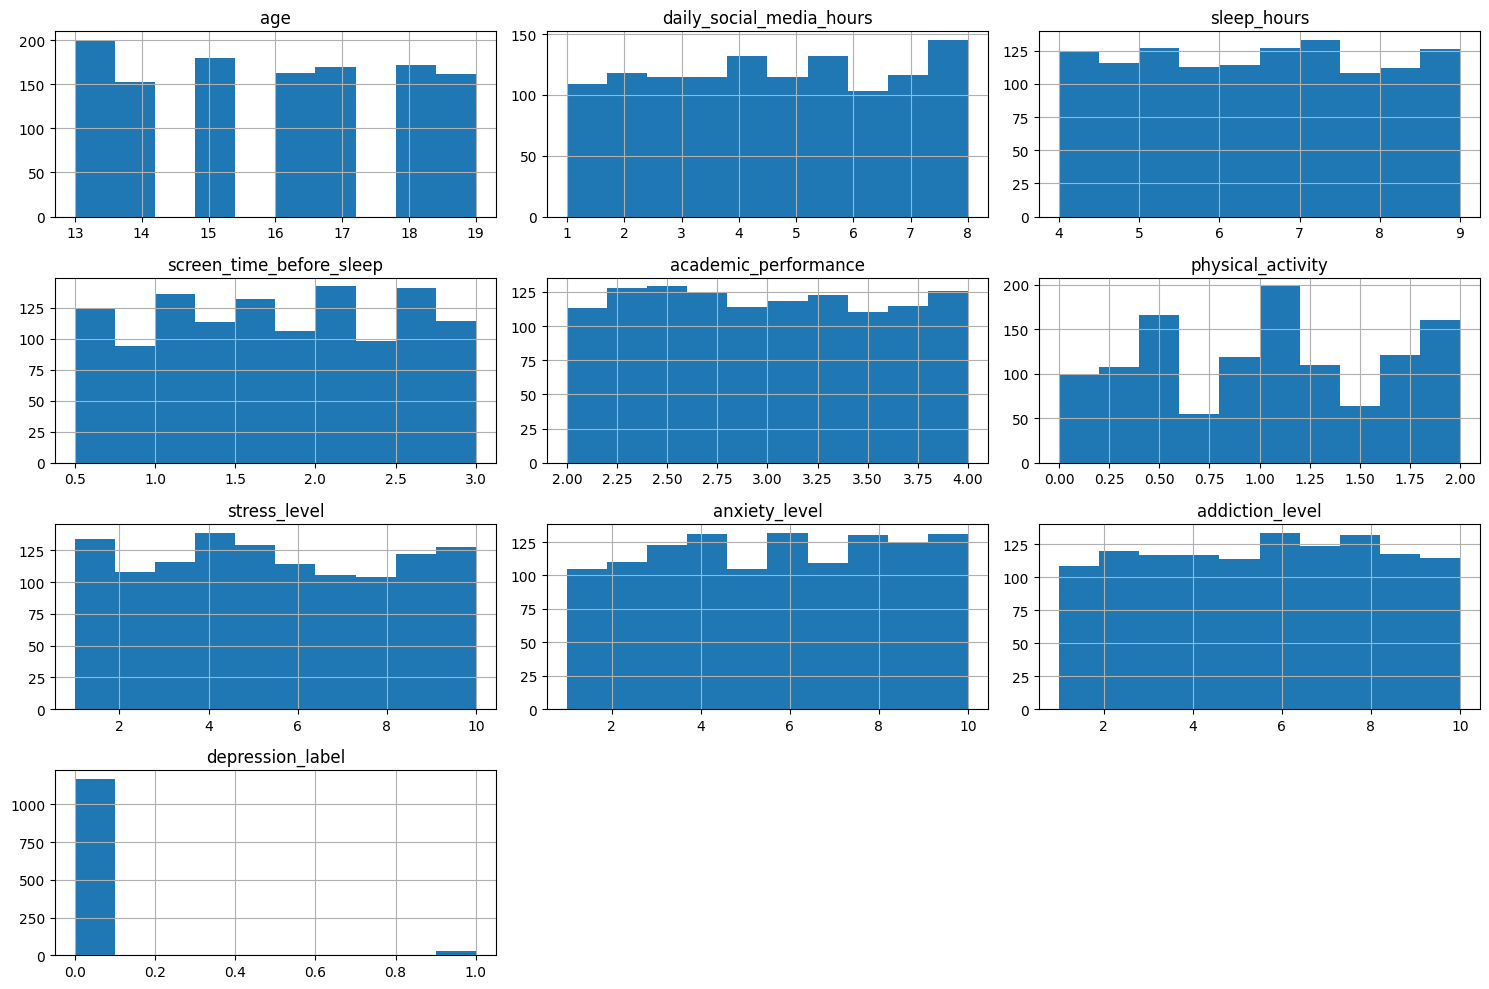

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

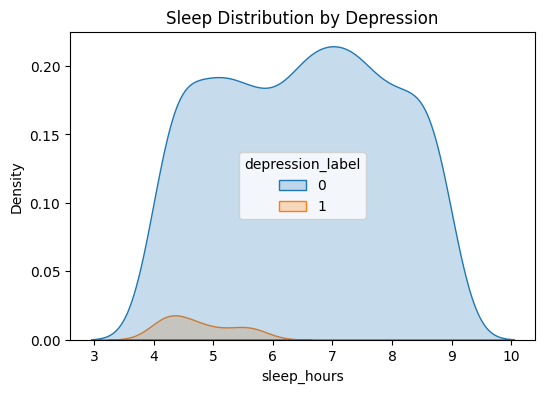

In [35]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x='sleep_hours', hue='depression_label', fill=True)
plt.title("Sleep Distribution by Depression")
plt.show()

In [36]:
df['platform_usage'] = df['platform_usage'].str.strip().str.title()
df['social_interaction_level'] = df['social_interaction_level'].str.lower()

In [37]:
df['platform_usage'].value_counts()
df['social_interaction_level'].value_counts()

social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64

In [38]:
print(df['platform_usage'].value_counts())
df['gender'].value_counts()

platform_usage
Instagram    411
Tiktok       398
Both         391
Name: count, dtype: int64


gender
male      615
female    585
Name: count, dtype: int64

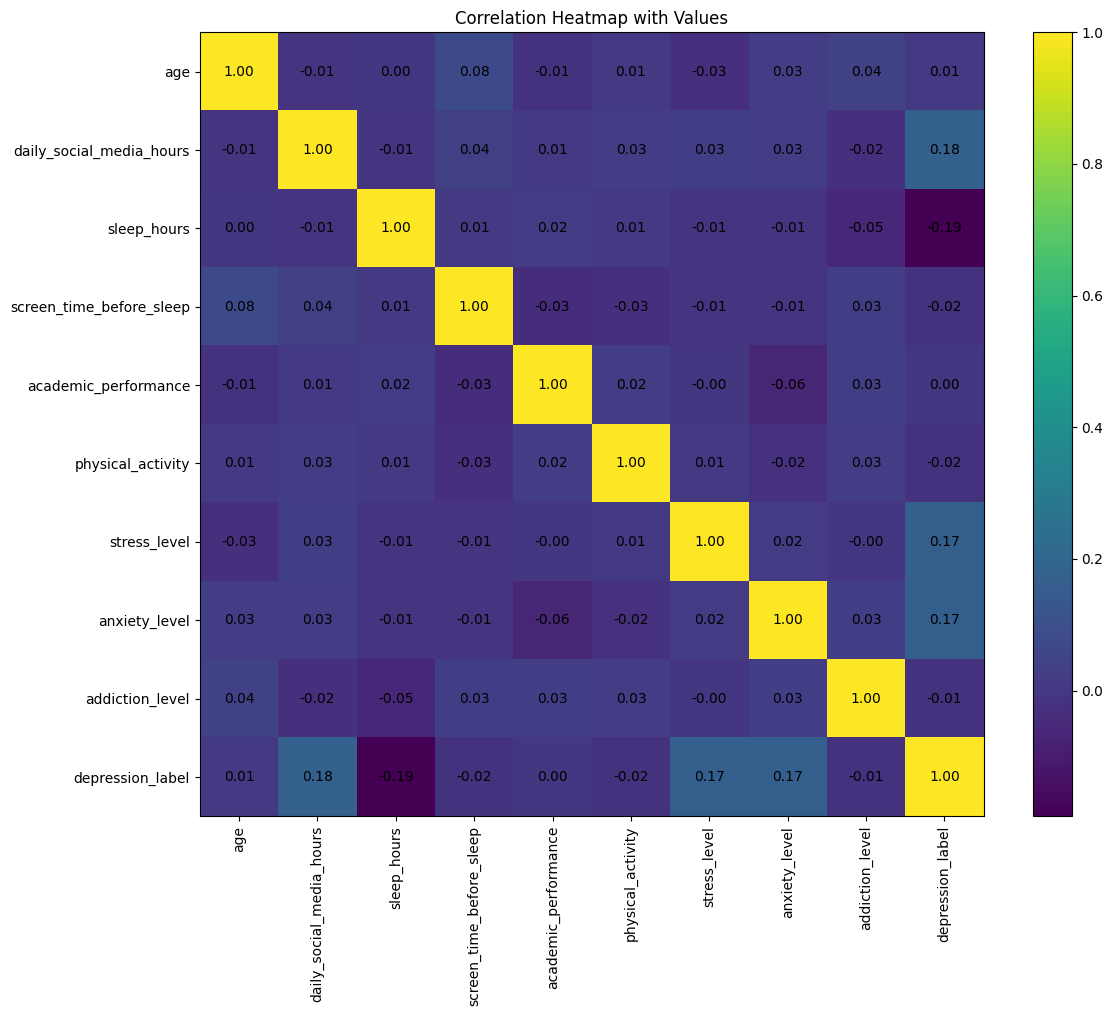

In [39]:
# Select numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation matrix
correlation_matrix = numeric_df.corr()

# ==========================================
# PLOT
# ==========================================

fig, ax = plt.subplots(figsize=(12, 10))

# Heatmap
heatmap = ax.imshow(correlation_matrix)

# Colorbar
plt.colorbar(heatmap)

# Labels
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=90
)

ax.set_yticklabels(
    correlation_matrix.columns
)

# ==========================================
# ADD CORRELATION VALUES INSIDE CELLS
# ==========================================

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):

        value = correlation_matrix.iloc[i, j]

        ax.text(
            j,                  # x position
            i,                  # y position
            f"{value:.2f}",     # format with 2 decimals
            ha='center',
            va='center'
        )

# ==========================================
# TITLE
# ==========================================

plt.title("Correlation Heatmap with Values")

plt.tight_layout()

plt.show()

In [40]:
print(df.groupby("gender")[["stress_level",
                            "anxiety_level",
                            "addiction_level"]].mean())

        stress_level  anxiety_level  addiction_level
gender                                              
female      5.422222       5.687179          5.48547
male        5.468293       5.588618          5.64065


        stress_level  anxiety_level  addiction_level
gender                                              
female      5.422222       5.687179          5.48547
male        5.468293       5.588618          5.64065


<Axes: xlabel='gender'>

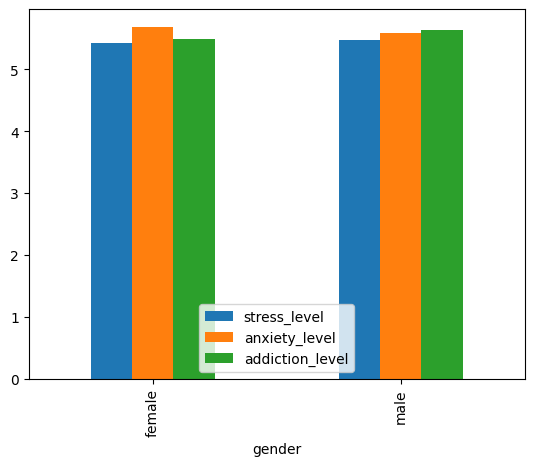

In [41]:
result=df.groupby('gender')[['stress_level','anxiety_level','addiction_level']].mean()
print(result)
result.plot(kind='bar')

In [42]:
df.groupby(['gender','platform_usage'])['daily_social_media_hours'].mean()


gender  platform_usage
female  Both              4.547090
        Instagram         4.468473
        Tiktok            4.526425
male    Both              4.491584
        Instagram         4.648077
        Tiktok            4.535610
Name: daily_social_media_hours, dtype: float64

<Axes: xlabel='gender'>

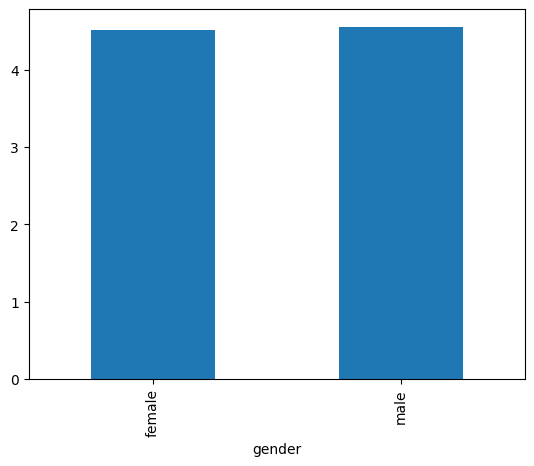

In [43]:
df.groupby("gender")["daily_social_media_hours"].mean().plot(kind="bar")

In [44]:
df[['sleep_hours','daily_social_media_hours']].corr()

,sleep_hours,daily_social_media_hours
sleep_hours,1.000000,-0.009472
daily_social_media_hours,-0.009472,1.000000


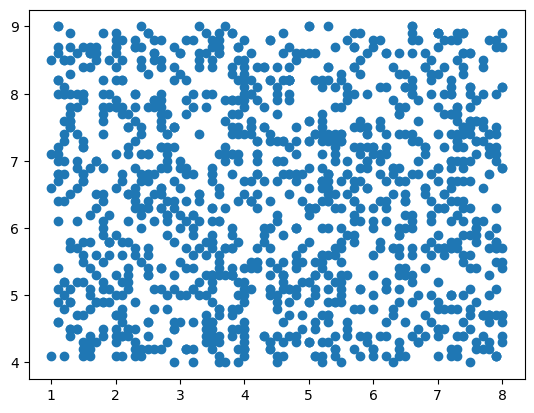

In [45]:
import matplotlib.pyplot as plt
plt.scatter(df["daily_social_media_hours"], df["sleep_hours"])
plt.show()

In [46]:
df.groupby("gender")["academic_performance"].mean()


gender
female    3.000547
male      2.980715
Name: academic_performance, dtype: float64

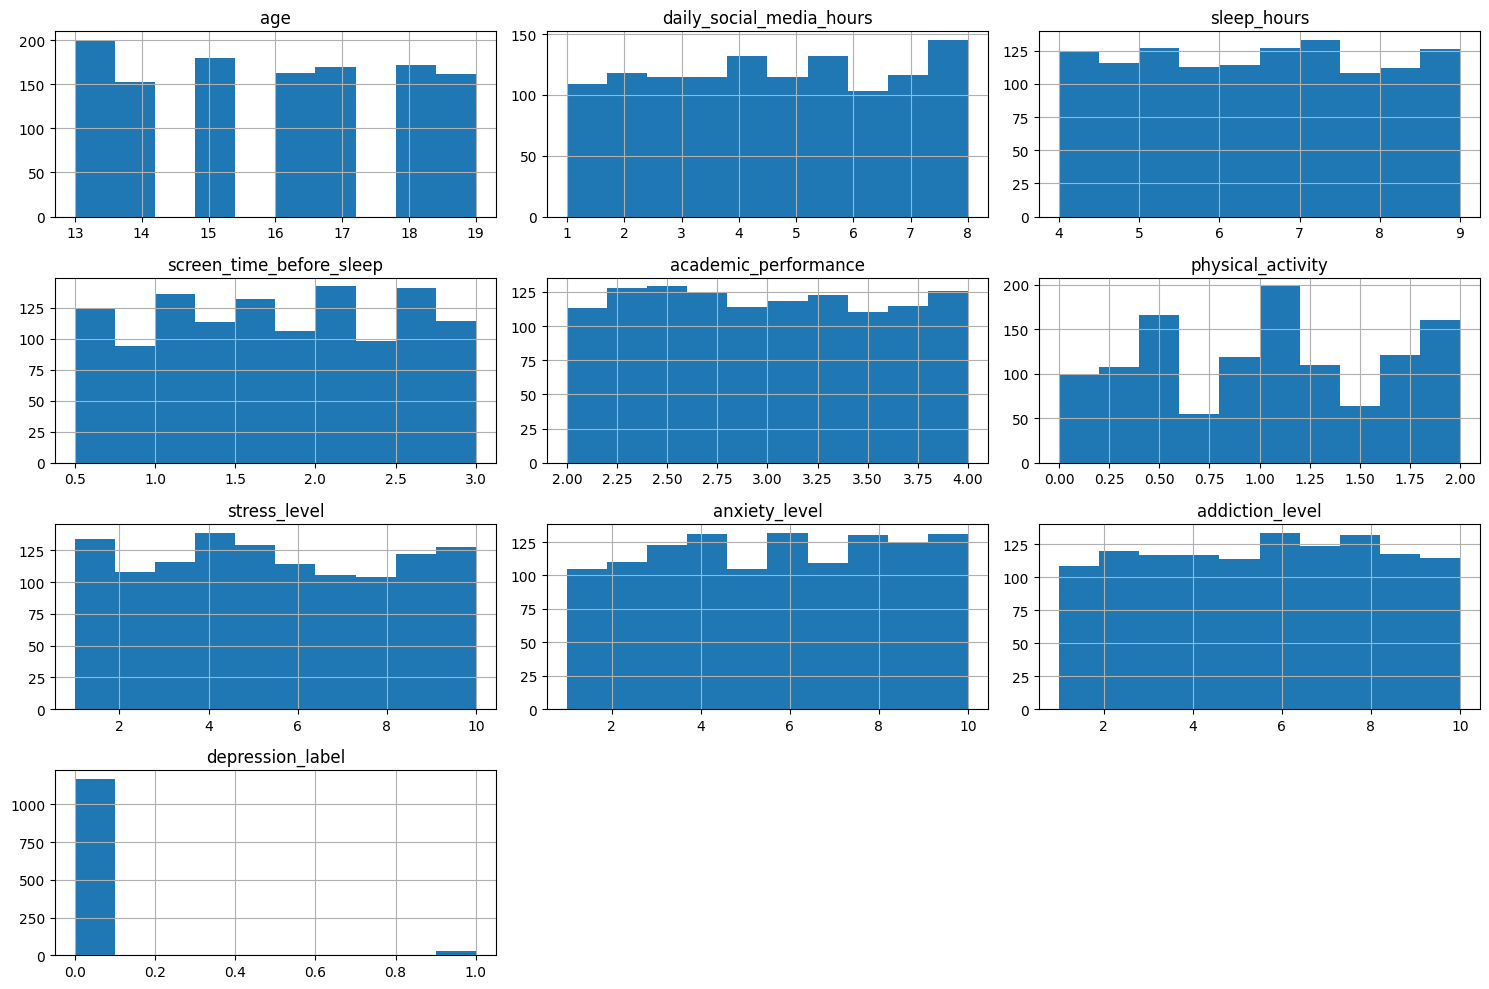

In [47]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

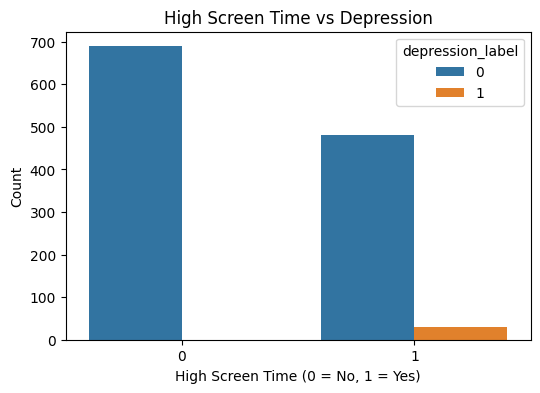

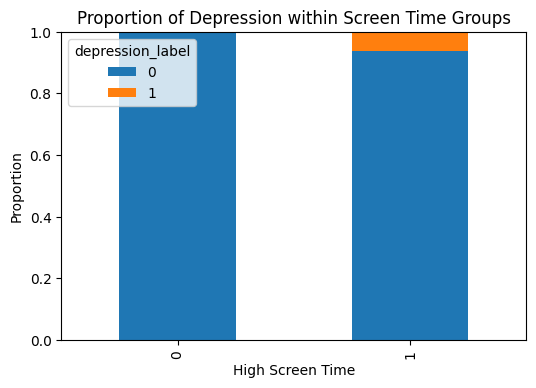

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- SAFETY: Ensure required columns exist ---
required_cols = ['daily_social_media_hours', 'depression_label']

for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in dataset. Check column names using df.columns")

# --- Convert to numeric safely ---
df['daily_social_media_hours'] = pd.to_numeric(df['daily_social_media_hours'], errors='coerce')

# --- Create feature safely ---
df['high_screen_time'] = df['daily_social_media_hours'].apply(
    lambda x: 1 if pd.notnull(x) and x > 5 else 0
)

# --- Drop rows with missing target (important for plotting) ---
df = df.dropna(subset=['depression_label'])

# --- Plot (Error-free version) ---
plt.figure(figsize=(6,4))
sns.countplot(x=df['high_screen_time'], hue=df['depression_label'])
plt.title("High Screen Time vs Depression")
plt.xlabel("High Screen Time (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# --- Bonus: Proportion Plot (Better Insight) ---
ct = pd.crosstab(df['high_screen_time'], df['depression_label'], normalize='index')

ct.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title("Proportion of Depression within Screen Time Groups")
plt.ylabel("Proportion")
plt.xlabel("High Screen Time")
plt.show()

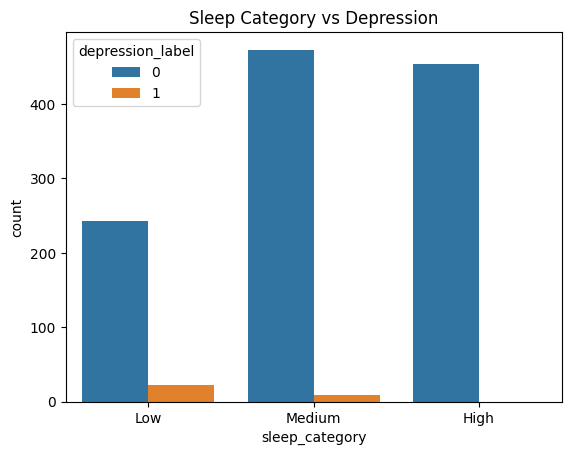

In [49]:
df['sleep_category'] = pd.cut(df['sleep_hours'], bins=[0,5,7,10], labels=['Low','Medium','High'])

sns.countplot(x='sleep_category', hue='depression_label', data=df)
plt.title("Sleep Category vs Depression")
plt.show()

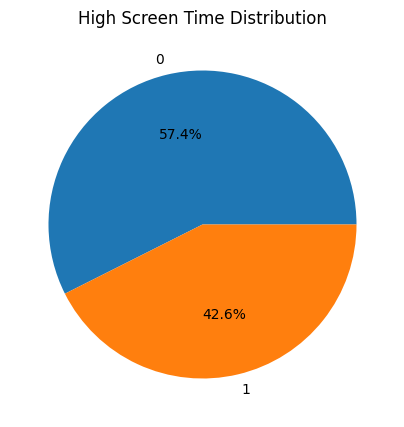

In [50]:
df['high_screen_time'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(5,5))
plt.title("High Screen Time Distribution")
plt.ylabel('')
plt.show()

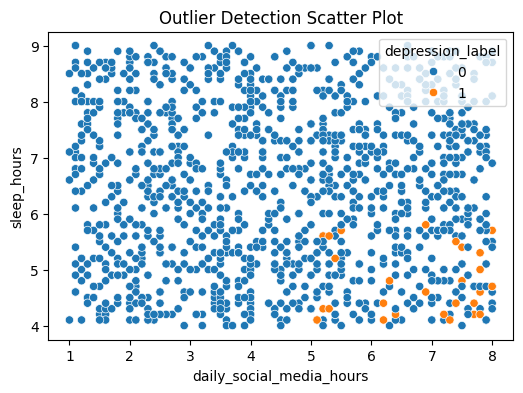

In [51]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='daily_social_media_hours', y='sleep_hours', hue='depression_label', data=df)
plt.title("Outlier Detection Scatter Plot")
plt.show()

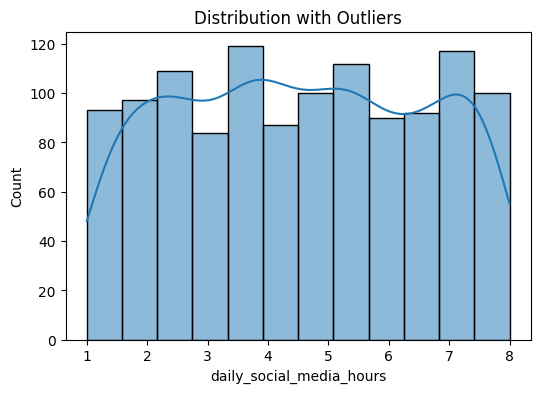

In [52]:
plt.figure(figsize=(6,4))
sns.histplot(df['daily_social_media_hours'], kde=True)
plt.title("Distribution with Outliers")
plt.show()

In [53]:
Q1 = df['daily_social_media_hours'].quantile(0.25)
Q3 = df['daily_social_media_hours'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['daily_social_media_hours'] < Q1 - 1.5*IQR) | 
              (df['daily_social_media_hours'] > Q3 + 1.5*IQR)]

print("Number of outliers:", len(outliers))

Number of outliers: 0


In [54]:
df['depression_label'].value_counts(normalize=True)

depression_label
0    0.974167
1    0.025833
Name: proportion, dtype: float64